## DAT param

In [10]:
import os
import numpy as np
import pandas as pd

file_path = './260416_Data_for_figures.xlsx'

df_raw = pd.read_excel(file_path, sheet_name='5a_b', engine='openpyxl')
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains("Unnamed:")]

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_filtered = df_raw.copy()
df_filtered = df_filtered[df_filtered['GDC'] == 'on']
df_filtered = df_filtered[df_filtered['IOparameter'] == 'ideal']
df_filtered = df_filtered[df_filtered['drift_noise_scale'] == 1]
df_filtered = df_filtered[df_filtered['read_noise_scale'] == 0]
df_filtered = df_filtered[df_filtered['inf_time'] == 93312000]  # 3yr
df_filtered = df_filtered[df_filtered['mapping_method'] == 'naive']
df_filtered = df_filtered[df_filtered['retrain'] != 'X']

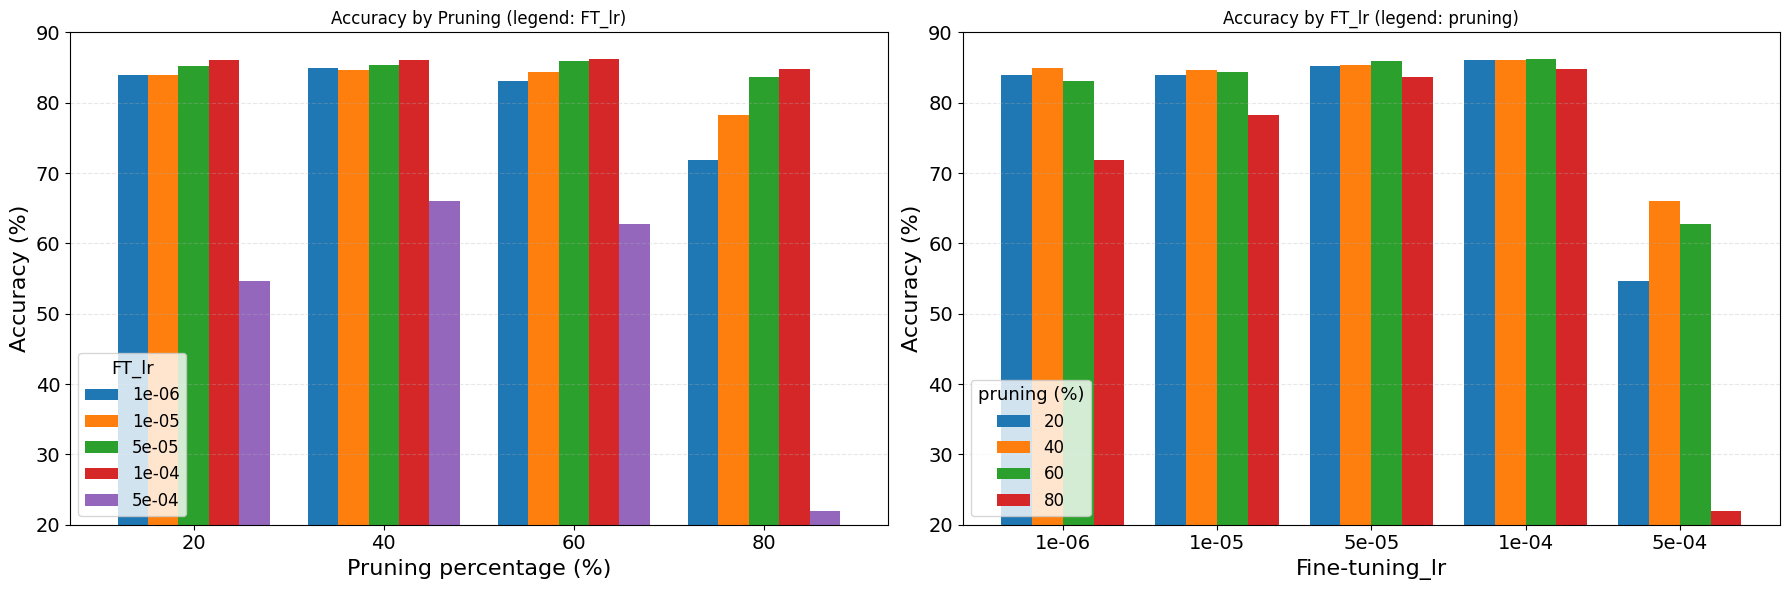

In [39]:
plot_df = df_filtered.copy() 
plot_df = plot_df[plot_df['accuracy'].notna()].copy() 
plot_df = plot_df[plot_df['pruning'] != '-'].copy() 
plot_df = plot_df[plot_df['FT_lr'] != '-'].copy() 

desired_pruning_order = [0.2, 0.4, 0.6, 0.8]
plot_df = plot_df[plot_df['pruning'].isin(desired_pruning_order)].copy()

plot_df['pruning'] = plot_df['pruning'].astype(float) 
plot_df['FT_lr'] = plot_df['FT_lr'].astype(float) 

pivot_pruning = plot_df.pivot_table( 
                                    index='pruning', columns='FT_lr', values='accuracy', aggfunc='mean' 
                                    ).sort_index().sort_index(axis=1) 

pivot_lr = plot_df.pivot_table( 
                               index='FT_lr', columns='pruning', values='accuracy', aggfunc='mean'
                               ).sort_index().sort_index(axis=1) 


fig, axes = plt.subplots(1, 2, figsize=(18, 6)) 
pivot_pruning.plot(kind='bar', ax=axes[0], width=0.8) 

axes[0].set_title('Accuracy by Pruning (legend: FT_lr)') 
axes[0].set_xlabel('Pruning percentage (%)', fontsize=16 ) 
axes[0].set_ylabel('Accuracy (%)', fontsize=16) 
axes[0].legend(title='FT_lr') 
axes[0].grid(axis='y', linestyle='--', alpha=0.3) 

# Change x-tick labels: 0.2 -> 20, 0.4 -> 40, ...
axes[0].set_xticklabels([f'{int(x * 100)}' for x in pivot_pruning.index], fontsize=14)
axes[0].tick_params(axis='y', labelsize=14)
axes[0].legend(
    [f'{x:.0e}' for x in pivot_pruning.columns],
    title='FT_lr',
    fontsize=12,         # legend entry fontsize
    title_fontsize=13,   # legend title fontsize
    loc='lower left'    # legend position
)

pivot_lr.plot(kind='bar', ax=axes[1], width=0.8) 
axes[1].set_title('Accuracy by FT_lr (legend: pruning)') 
axes[1].set_xlabel('Fine-tuning_lr', fontsize=16) 
axes[1].set_ylabel('Accuracy (%)', fontsize=16) 
axes[1].legend(title='pruning') 
axes[1].grid(axis='y', linestyle='--', alpha=0.3) 

# x-tick fontsize for right plot too
axes[1].tick_params(axis='x', labelsize=14)
axes[1].tick_params(axis='y', labelsize=14)
axes[1].legend(
    [f'{int(float(c) * 100)}' for c in pivot_lr.columns],
    title='pruning (%)',
    fontsize=12,
    title_fontsize=13,
    loc='lower left'
)
axes[1].set_xticklabels([f'{x:.0e}' for x in pivot_lr.index])

for ax in axes: 
    ax.tick_params(axis='x', rotation=0) 
    
axes[0].set_ylim(20, 90)
axes[1].set_ylim(20, 90)

plt.tight_layout()
plt.show()

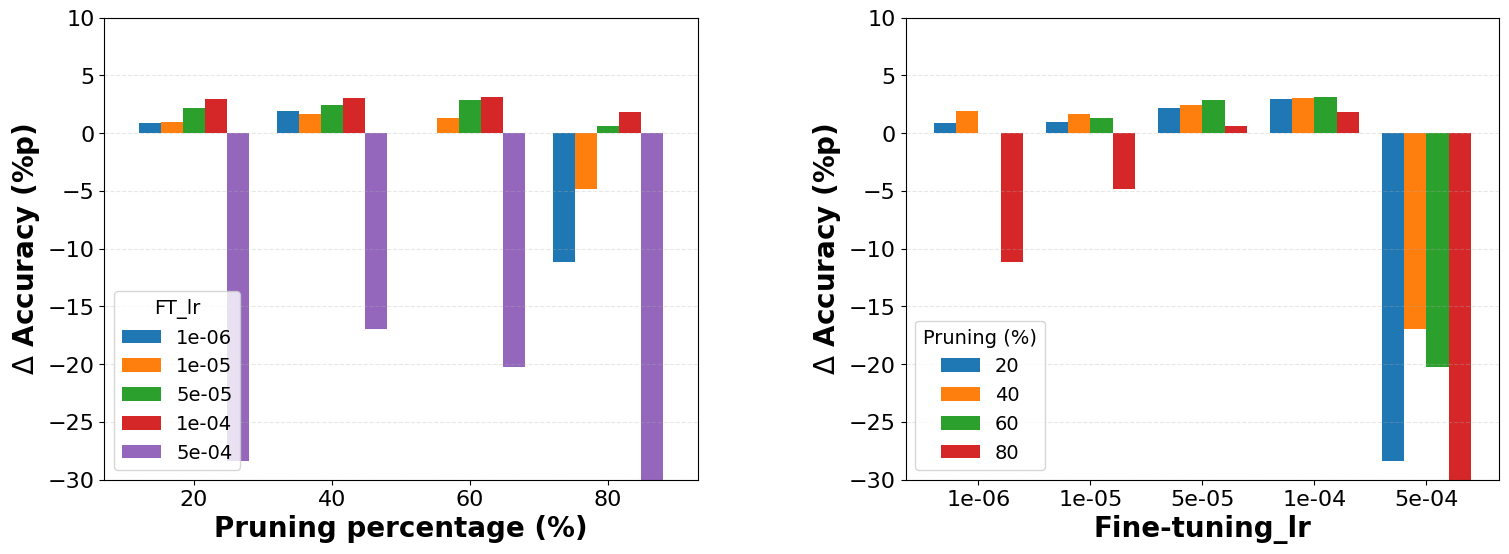

In [78]:
plot_df = df_filtered.copy() 
plot_df = plot_df[plot_df['accuracy'].notna()].copy() 
plot_df = plot_df[plot_df['pruning'] != '-'].copy() 
plot_df = plot_df[plot_df['FT_lr'] != '-'].copy() 

desired_pruning_order = [0.2, 0.4, 0.6, 0.8]
plot_df = plot_df[plot_df['pruning'].isin(desired_pruning_order)].copy()

plot_df['pruning'] = plot_df['pruning'].astype(float) 
plot_df['FT_lr'] = plot_df['FT_lr'].astype(float) 

pivot_pruning = plot_df.pivot_table( 
                                    index='pruning', columns='FT_lr', values='note', aggfunc='mean' 
                                    ).sort_index().sort_index(axis=1) 

pivot_lr = plot_df.pivot_table( 
                               index='FT_lr', columns='pruning', values='note', aggfunc='mean'
                               ).sort_index().sort_index(axis=1) 


fig, axes = plt.subplots(1, 2, figsize=(18, 6)) 
fig.subplots_adjust(wspace=0.35)
pivot_pruning.plot(kind='bar', ax=axes[0], width=0.8) 

# axes[0].set_title('Accuracy by Pruning (legend: FT_lr)') 
axes[0].set_xlabel('Pruning percentage (%)', fontsize=20, fontweight='bold' ) 
axes[0].set_ylabel(r'$\Delta$ Accuracy (%p)', fontsize=20, fontweight='bold') 
axes[0].legend(title='FT_lr') 
axes[0].grid(axis='y', linestyle='--', alpha=0.3) 

# Change x-tick labels: 0.2 -> 20, 0.4 -> 40, ...
axes[0].set_xticklabels([f'{int(x * 100)}' for x in pivot_pruning.index], fontsize=16)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].legend(
    [f'{x:.0e}' for x in pivot_pruning.columns],
    title='FT_lr',
    fontsize=14,         # legend entry fontsize
    title_fontsize=14,   # legend title fontsize
    loc='lower left'    # legend position
)

pivot_lr.plot(kind='bar', ax=axes[1], width=0.8) 
# axes[1].set_title('Accuracy by FT_lr (legend: pruning)') 
axes[1].set_xlabel('Fine-tuning_lr', fontsize=20, fontweight='bold') 
axes[1].set_ylabel(r'$\Delta$ Accuracy (%p)', fontsize=20, fontweight='bold') 
axes[1].legend(title='pruning') 
axes[1].grid(axis='y', linestyle='--', alpha=0.3) 

# x-tick fontsize for right plot too
axes[1].tick_params(axis='x', labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].legend(
    [f'{int(float(c) * 100)}' for c in pivot_lr.columns],
    title='Pruning (%)',
    fontsize=14,
    title_fontsize=14,
    loc='lower left'
)
axes[1].set_xticklabels([f'{x:.0e}' for x in pivot_lr.index])

for ax in axes: 
    ax.tick_params(axis='x', rotation=0) 
    
axes[0].set_ylim(-30, 10)
axes[1].set_ylim(-30, 10)

# plt.tight_layout()
plt.show()

## 